In [1]:
from math import sqrt

import numpy as np
import matplotlib.pyplot as plt

## 32. f(x) = x^4 - 8x + 10, [a,b] = [0,2], epsilon=0.5, n = 4, delta = 0.125

In [2]:
a, b = (0, 2)
epsilon = 0.5
n = 4
delta = 0.125

## Անալիտիկական լուծում

In [3]:
def f(x):
    return x**4 - 8*x + 10

def dfdx(x):
    return 4*x**3 - 8

# dfdx = 0 => x**3 = 2 => x = 2 ** (1/3)

x_min_analytical = 2 ** (1/3)
y_min_analytical = f(x_min_analytical)

print("Analytical solution")
print("x_min =", x_min_analytical)
print("f(x_min) =", y_min_analytical)

Analytical solution
x_min = 1.2599210498948732
f(x_min) = 2.4404737006307613


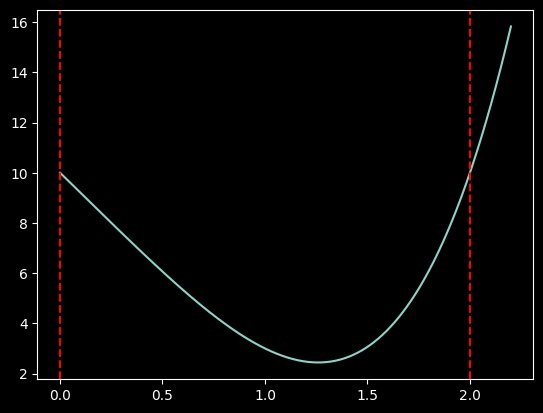

In [4]:
xplot = np.linspace(a*0.9, b*1.1, 1000)
yplot = f(xplot)
plt.plot(xplot, yplot)

plt.axvline(a, color='r', linestyle='--')
plt.axvline(b, color='r', linestyle='--')


## Ընտրանքների եղանակ

In [5]:
x_list_choosing = [a + k * (b - a)/n for k in range(n + 1)]
y_list_choosing = [f(x_i) for x_i in x_list_choosing]

print("\nChoosing method")
print("i\t x\t\t f(x)")
print("-" * 30)

for i in range(len(x_list_choosing)):
    print(f"{i}\t {x_list_choosing[i]:.6f}\t {y_list_choosing[i]:.6f}")

# best solution
min_index = y_list_choosing.index(min(y_list_choosing))
print("\nBest solution:")
print(f"x* = {x_list_choosing[min_index]:.6f}")
print(f"f(x*) = {y_list_choosing[min_index]:.6f}")


Choosing method
i	 x		 f(x)
------------------------------
0	 0.000000	 10.000000
1	 0.500000	 6.062500
2	 1.000000	 3.000000
3	 1.500000	 3.062500
4	 2.000000	 10.000000

Best solution:
x* = 1.000000
f(x*) = 3.000000


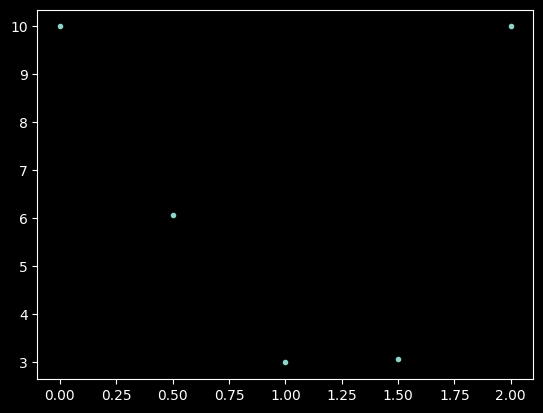

In [6]:
plt.plot(x_list_choosing, y_list_choosing, '.')

## Հատվածի կիսման եղանակ

In [7]:
x1_list_halving = []
x2_list_halving = []

a_list_halving = [a]
b_list_halving = [b]

x1_list_halving.append((a + b - delta) / 2)
x2_list_halving.append((a + b + delta) / 2)

while abs(b_list_halving[-1] - a_list_halving[-1]) > epsilon:
    if f(x1_list_halving[-1]) <= f(x2_list_halving[-1]):
        a_list_halving.append(a_list_halving[-1])
        b_list_halving.append(x2_list_halving[-1])
    else:
        a_list_halving.append(x1_list_halving[-1])
        b_list_halving.append(b_list_halving[-1])

    x1_list_halving.append((a_list_halving[-1] + b_list_halving[-1] - delta) / 2)
    x2_list_halving.append((a_list_halving[-1] + b_list_halving[-1] + delta) / 2)

In [8]:
x_list_halving = [(a_list_halving[i] + b_list_halving[i]) /2 for i in range(len(b_list_halving))]
y_list_halving = [f(i) for i in x_list_halving]

print("\nInterval halving method")
print("i\t x\t\t f(x)")
print("-" * 30)

for i in range(len(x_list_halving)):
    print(f"{i}\t {x_list_halving[i]:.6f}\t {y_list_halving[i]:.6f}")

# final solution
print("\nFinal solution:")
print(f"x* = {x_list_halving[-1]:.6f}")
print(f"f(x*) = {y_list_halving[-1]:.6f}")


Interval halving method
i	 x		 f(x)
------------------------------
0	 1.000000	 3.000000
1	 1.468750	 2.903626
2	 1.234375	 2.446606
3	 1.351562	 2.524410

Final solution:
x* = 1.351562
f(x*) = 2.524410


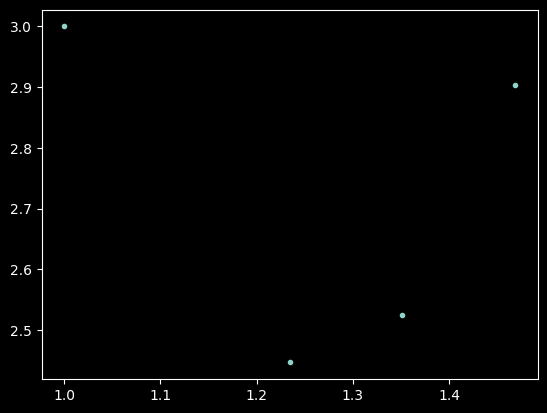

In [9]:
plt.plot(x_list_halving, y_list_halving, '.')

## Ոսկե հատույթի եղանակ

In [10]:
x1_list_golden = []
x2_list_golden = []

a_list_golden = [a]
b_list_golden = [b]

x1_list_golden.append(a_list_golden[0] + (3 - sqrt(5)) / 2 * (b_list_golden[0] - a_list_golden[0]))
x2_list_golden.append(a_list_golden[0] + (sqrt(5) - 1) / 2 * (b_list_golden[0] - a_list_golden[0]))

while abs(b_list_golden[-1] - a_list_golden[-1]) > epsilon:
    if f(x1_list_golden[-1]) <= f(x2_list_golden[-1]):
        a_list_golden.append(a_list_golden[-1])
        b_list_golden.append(x2_list_golden[-1])
        x2_list_golden.append(x1_list_golden[-1])
        x1_list_golden.append(a_list_golden[-1] + b_list_golden[-1] - x1_list_golden[-1])
    else:
        a_list_golden.append(x1_list_golden[-1])
        b_list_golden.append(b_list_golden[-1])
        x1_list_golden.append(x2_list_golden[-1])
        x2_list_golden.append(a_list_golden[-1] + b_list_golden[-1] - x2_list_golden[-1])

In [11]:
x_list_golden = [(x1_list_golden[i] + x2_list_golden[i]) /2 for i in range(len(x1_list_golden))]
y_list_golden = [f(i) for i in x_list_golden]

print("\nGolden section search")
print("i\t x\t\t f(x)")
print("-" * 30)

for i in range(len(x_list_golden)):
    print(f"{i}\t {x_list_golden[i]:.6f}\t {y_list_golden[i]:.6f}")

# final solution
print("\nFinal solution:")
print(f"x* = {x_list_golden[-1]:.6f}")
print(f"f(x*) = {y_list_golden[-1]:.6f}")


Golden section search
i	 x		 f(x)
------------------------------
0	 1.000000	 3.000000
1	 1.381966	 2.591723
2	 1.145898	 2.557001
3	 1.291796	 2.450315

Final solution:
x* = 1.291796
f(x*) = 2.450315


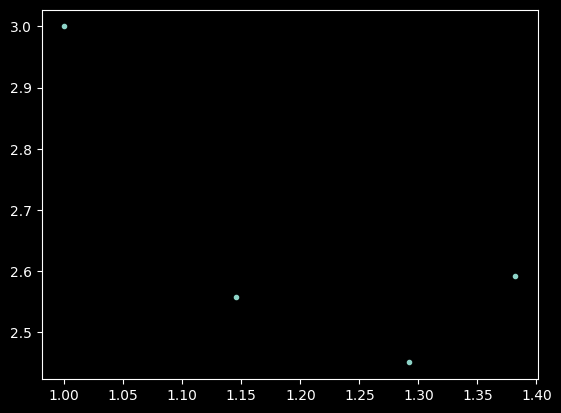

In [12]:
plt.plot(x_list_golden, y_list_golden, '.')